In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# 1) LOAD ONLY PREDICTIONS
# ============================================================

# ---------- SOCAT ----------
predictions_socat = pd.read_csv(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/matrix_predictions/"
    "pco2_prediction_matrix_SOCAT_only_MCensemble.csv"
)

predictions_socat["month_center"] = pd.to_datetime(predictions_socat["month_center"])
predictions_socat = predictions_socat[
    ~((predictions_socat["month_center"].dt.year == 2023) &
      (predictions_socat["month_center"].dt.month == 2))
]

# ---------- FLOATS ----------
predictions_floats = pd.read_csv(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/matrix_predictions/"
    "pco2_prediction_matrix_FLOATS_only_MCensemble.csv"
)

predictions_floats["month_center"] = pd.to_datetime(predictions_floats["month_center"])
predictions_floats = predictions_floats[
    ~((predictions_floats["month_center"].dt.year == 2023) &
      (predictions_floats["month_center"].dt.month == 2))
]


# ============================================================
# 2) ADD SEASON LABELS
# ============================================================

def assign_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"

for df in [predictions_socat, predictions_floats]:
    df["month"] = df["month_center"].dt.month
    df["season"] = df["month"].apply(assign_season)


# ============================================================
# 3) SEASONAL MEAN UNCERTAINTY PER GRID CELL AUTO-DETECT
# ============================================================

def seasonal_mean_uncertainty(df):
    """
    Returns mean ensemble uncertainty per season per grid cell
    Automatically detects:
      - latitude / longitude
      - OR lat_center / lon_center
    """

    if {"latitude", "longitude"}.issubset(df.columns):
        lat_col, lon_col = "latitude", "longitude"
    elif {"lat_center", "lon_center"}.issubset(df.columns):
        lat_col, lon_col = "lat_center", "lon_center"
    else:
        raise KeyError("No valid latitude/longitude columns found in dataframe.")

    out = (
        df
        .groupby(["season", lat_col, lon_col])["ensemble_pco2_std"]
        .mean()
        .reset_index()
        .rename(columns={lat_col: "latitude", lon_col: "longitude"})
    )

    return out


seasonal_socat  = seasonal_mean_uncertainty(predictions_socat)
seasonal_floats = seasonal_mean_uncertainty(predictions_floats)





/tmp/ipykernel_1785905/1513067933.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.10, 1, 0.96])


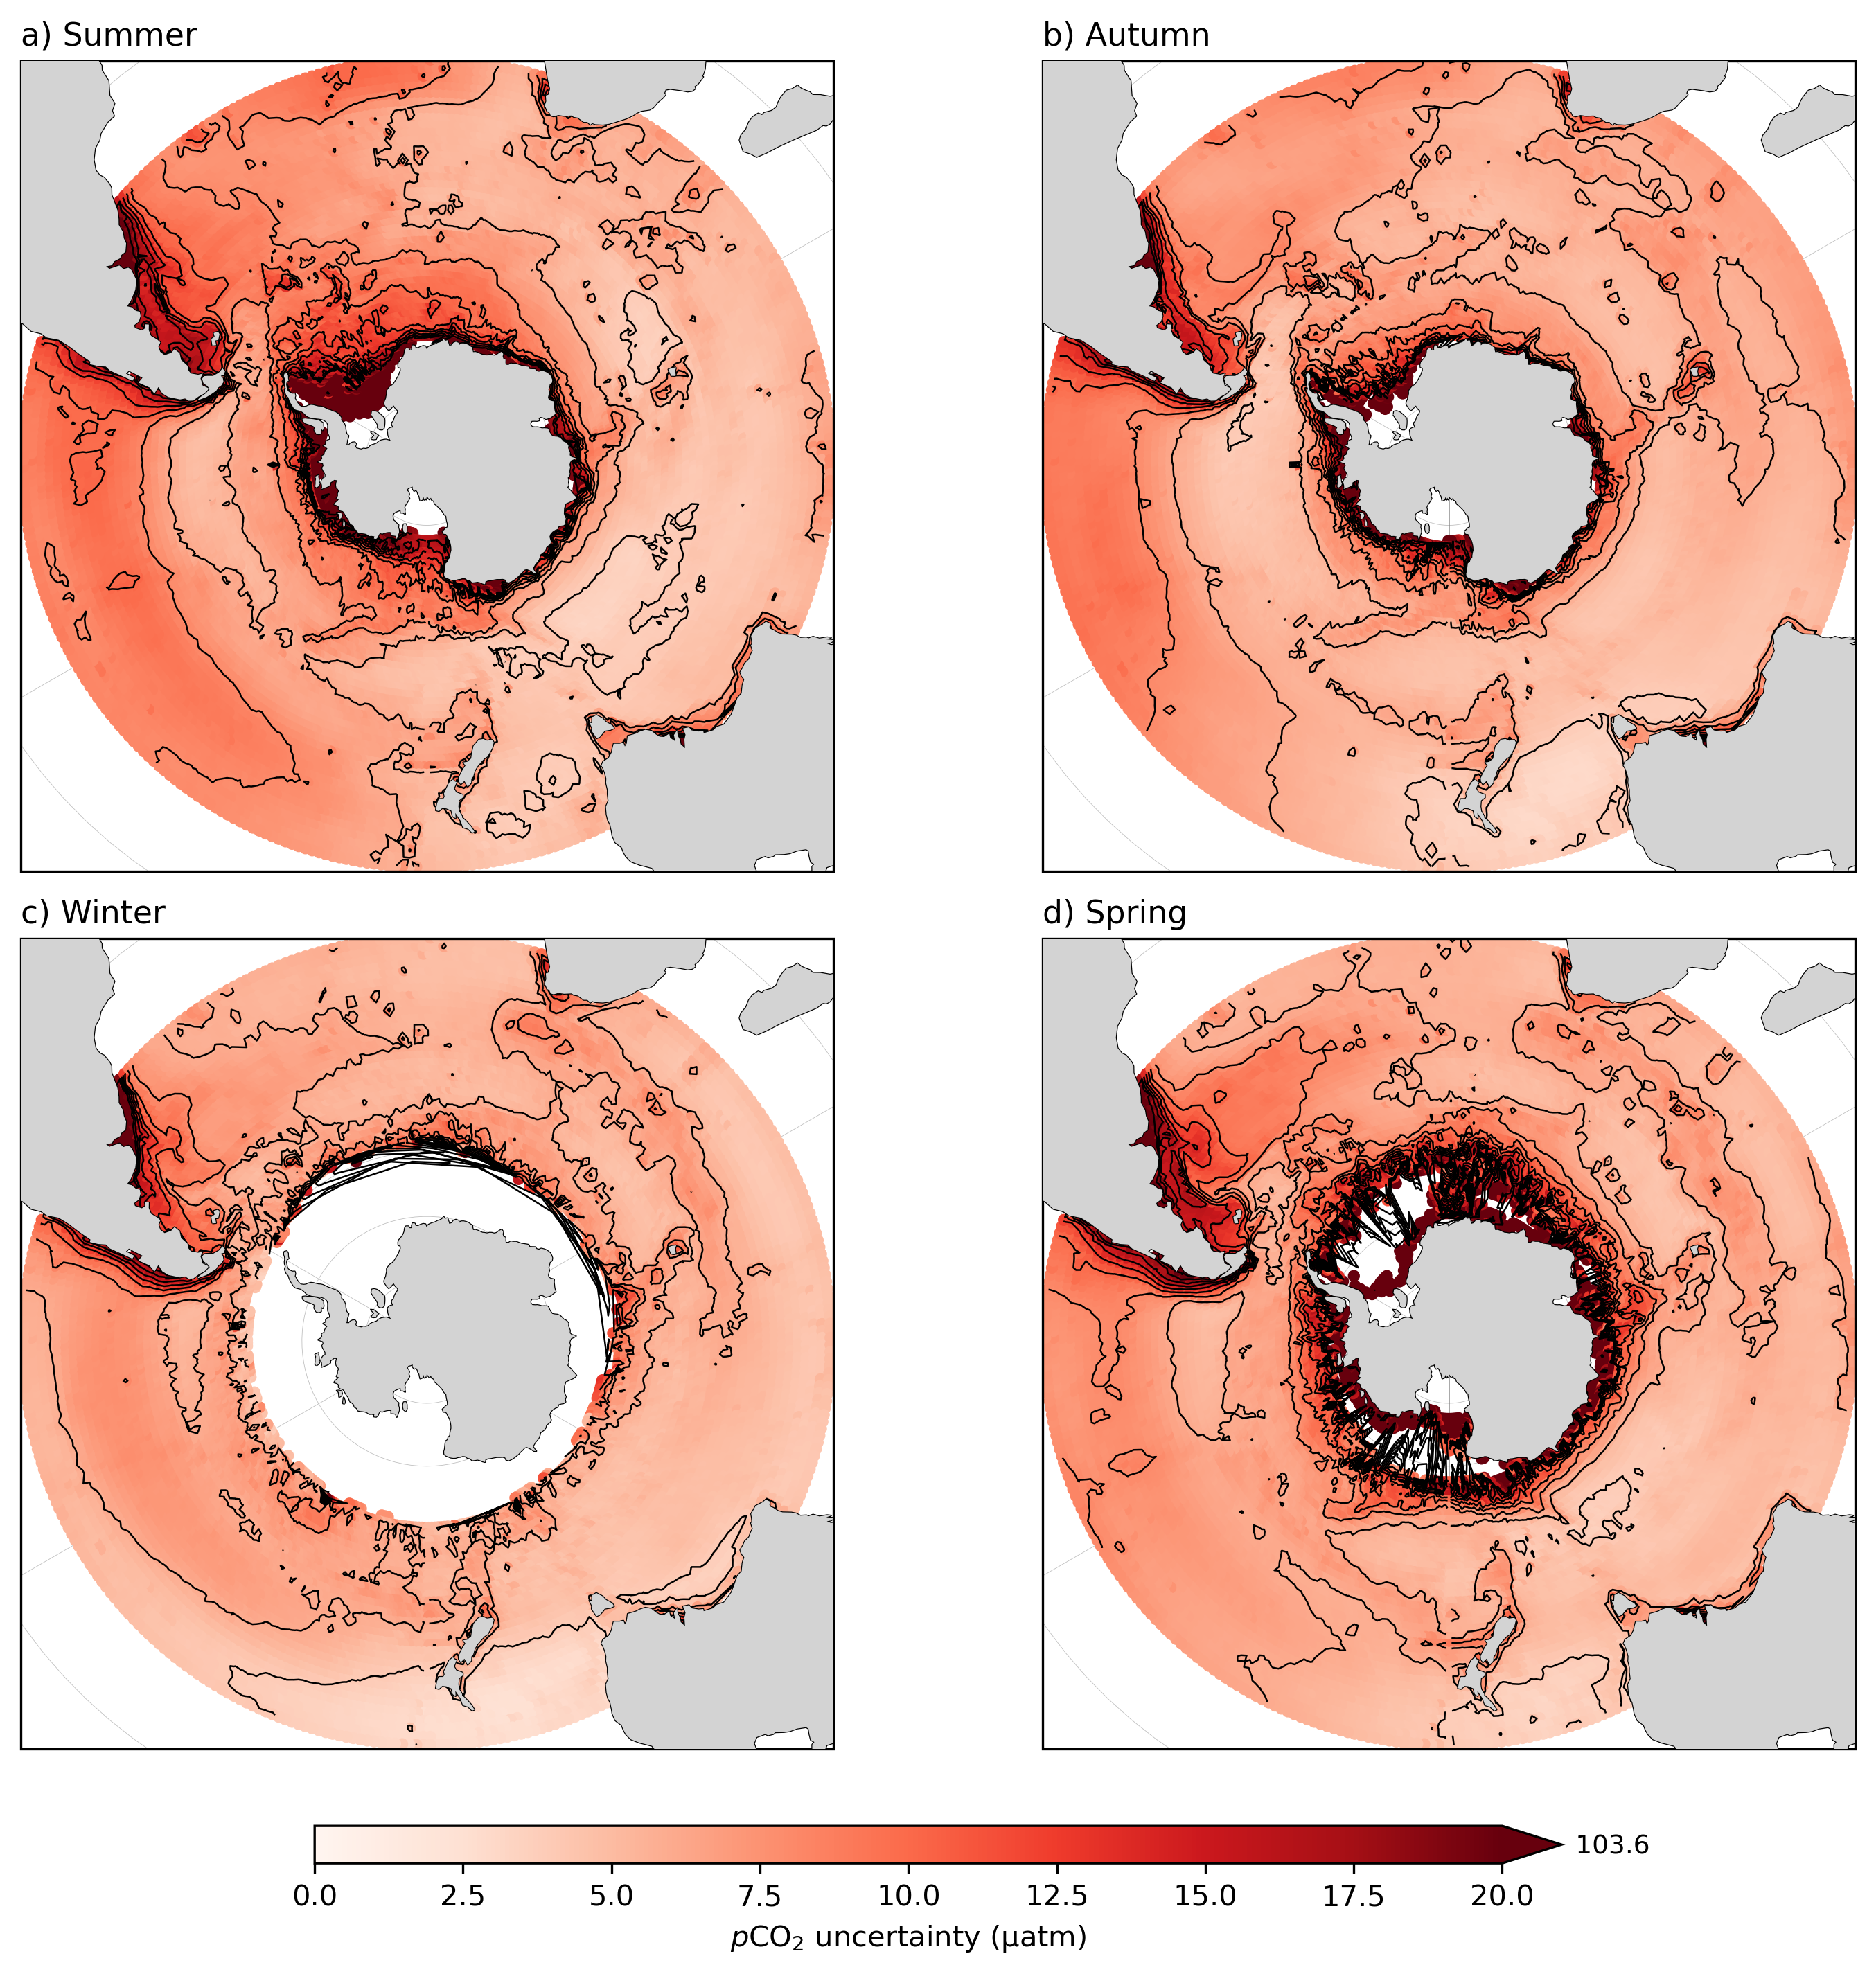

In [14]:
# ============================================================
# SOUTHERN OCEAN MAP PLOTTING FUNCTION (4 SEASONS)
# - Scatter uncertainty + contour lines (interval configurable)
# - Continents (LAND) drawn ON TOP of everything else
# - Full manual control of colorbar geometry
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize


def plot_seasonal_uncertainty_maps(
    df_seasonal,
    title_prefix,
    output_path,
    contour_step=5,          
    contour_min=None,        # optional: override contour min
    contour_max=None,        # optional: override contour max
    contour_color="k",
    contour_lw=0.6,
    contour_label=False,
    land_color="lightgray"
):
    """
    df_seasonal must contain columns:
      - longitude, latitude, ensemble_pco2_std, season
    """

    # Southern Hemisphere season order + labels
    season_order  = ["DJF", "MAM", "JJA", "SON"]
    season_labels = {
        "DJF": "Summer",
        "MAM": "Autumn",
        "JJA": "Winter",
        "SON": "Spring",
    }

    # Panel letters
    panel_letters = ["a", "b", "c", "d"]

    # ----------------------------------------
    # COLOR SCALING
    # ----------------------------------------
    vmin = 0.0
    vmax = 20.0
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = "Reds"

    true_max = df_seasonal["ensemble_pco2_std"].max()

    # ----------------------------------------
    # Contour level setup (interval configurable)
    # ----------------------------------------
    if contour_step is None or contour_step <= 0:
        raise ValueError("contour_step must be a positive number (e.g., 5).")

    cmin = vmin if contour_min is None else float(contour_min)
    cmax = vmax if contour_max is None else float(contour_max)

    contour_levels = np.arange(cmin, cmax + 0.1, float(contour_step))

    # ----------------------------------------
    # Figure with 4 polar map subplots
    # ----------------------------------------
    fig, axs = plt.subplots(
        2, 2,
        figsize=(10, 10),
        dpi=300,
        subplot_kw={"projection": ccrs.SouthPolarStereo()}
    )
    axs = axs.flatten()

    # Define land feature once (we will add it LAST in each panel)
    land_feature = cfeature.NaturalEarthFeature(
        "physical", "land", "110m",
        edgecolor="none",
        facecolor=land_color
    )

    for i, (ax, season) in enumerate(zip(axs, season_order)):

        ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

        # Gridlines first (bottom layer)
        ax.gridlines(draw_labels=False, linewidth=0.2, color="gray", alpha=0.5)

        df_s = df_seasonal[df_seasonal["season"] == season].copy()

        # Scatter plot (colored uncertainty)
        sc = ax.scatter(
            df_s["longitude"].values,
            df_s["latitude"].values,
            c=df_s["ensemble_pco2_std"].values,
            s=10,
            cmap=cmap,
            norm=norm,
            transform=ccrs.PlateCarree(),
            zorder=2
        )

        # Contours on top of scatter (but below land/continents)
        mask = (
            np.isfinite(df_s["longitude"].values) &
            np.isfinite(df_s["latitude"].values) &
            np.isfinite(df_s["ensemble_pco2_std"].values)
        )
        dff = df_s.loc[mask]

        if len(dff) >= 10:
            ct = ax.tricontour(
                dff["longitude"].values,
                dff["latitude"].values,
                dff["ensemble_pco2_std"].values,
                levels=contour_levels,
                colors=contour_color,
                linewidths=contour_lw,
                transform=ccrs.PlateCarree(),
                zorder=3
            )
            if contour_label:
                ax.clabel(ct, fmt="%g", fontsize=7, inline=True)

        # Coastlines above contours but still below land fill (optional preference)
        ax.coastlines(resolution="110m", linewidth=0.6, zorder=4)

        # ------------------------------------------------------------
        # LAND / CONTINENTS ON TOP OF EVERYTHING ELSE
        # ------------------------------------------------------------
        ax.add_feature(land_feature, zorder=10)

        # Panel label
        ax.text(
            0, 1.05,
            f"{panel_letters[i]}) {season_labels[season]}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=11
        )

    # ============================================================
    # FULL MANUAL CONTROL COLORBAR AXIS
    # ============================================================
    cax = fig.add_axes([
        0.20,   # left
        0.06,   # bottom
        0.60,   # width
        0.018   # height
    ])

    cbar = fig.colorbar(
        sc,
        cax=cax,
        orientation="horizontal",
        extend="max"
    )

    cbar.set_label(r"$p$CO$_2$ uncertainty (µatm)")

    # Annotate TRUE MAX next to arrow
    cbar.ax.text(
        1.02, 0.45,
        f"      {true_max:.1f}",
        transform=cbar.ax.transAxes,
        va="center",
        ha="left",
        fontsize=9
    )

    # Layout + save
    # fig.suptitle(f"{title_prefix} — Mean Seasonal MC Uncertainty", fontsize=14)
    plt.tight_layout(rect=[0, 0.10, 1, 0.96])
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================
# PLOT SOCAT SEASONAL UNCERTAINTY
# ============================================================

plot_seasonal_uncertainty_maps(
    seasonal_socat,
    "SOCAT Predictions",
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/figs/"
    "SOCAT_seasonal_MC_uncertainty_maps.png",
    contour_step=2
)


/tmp/ipykernel_1785905/1992085103.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.10, 1, 0.96])


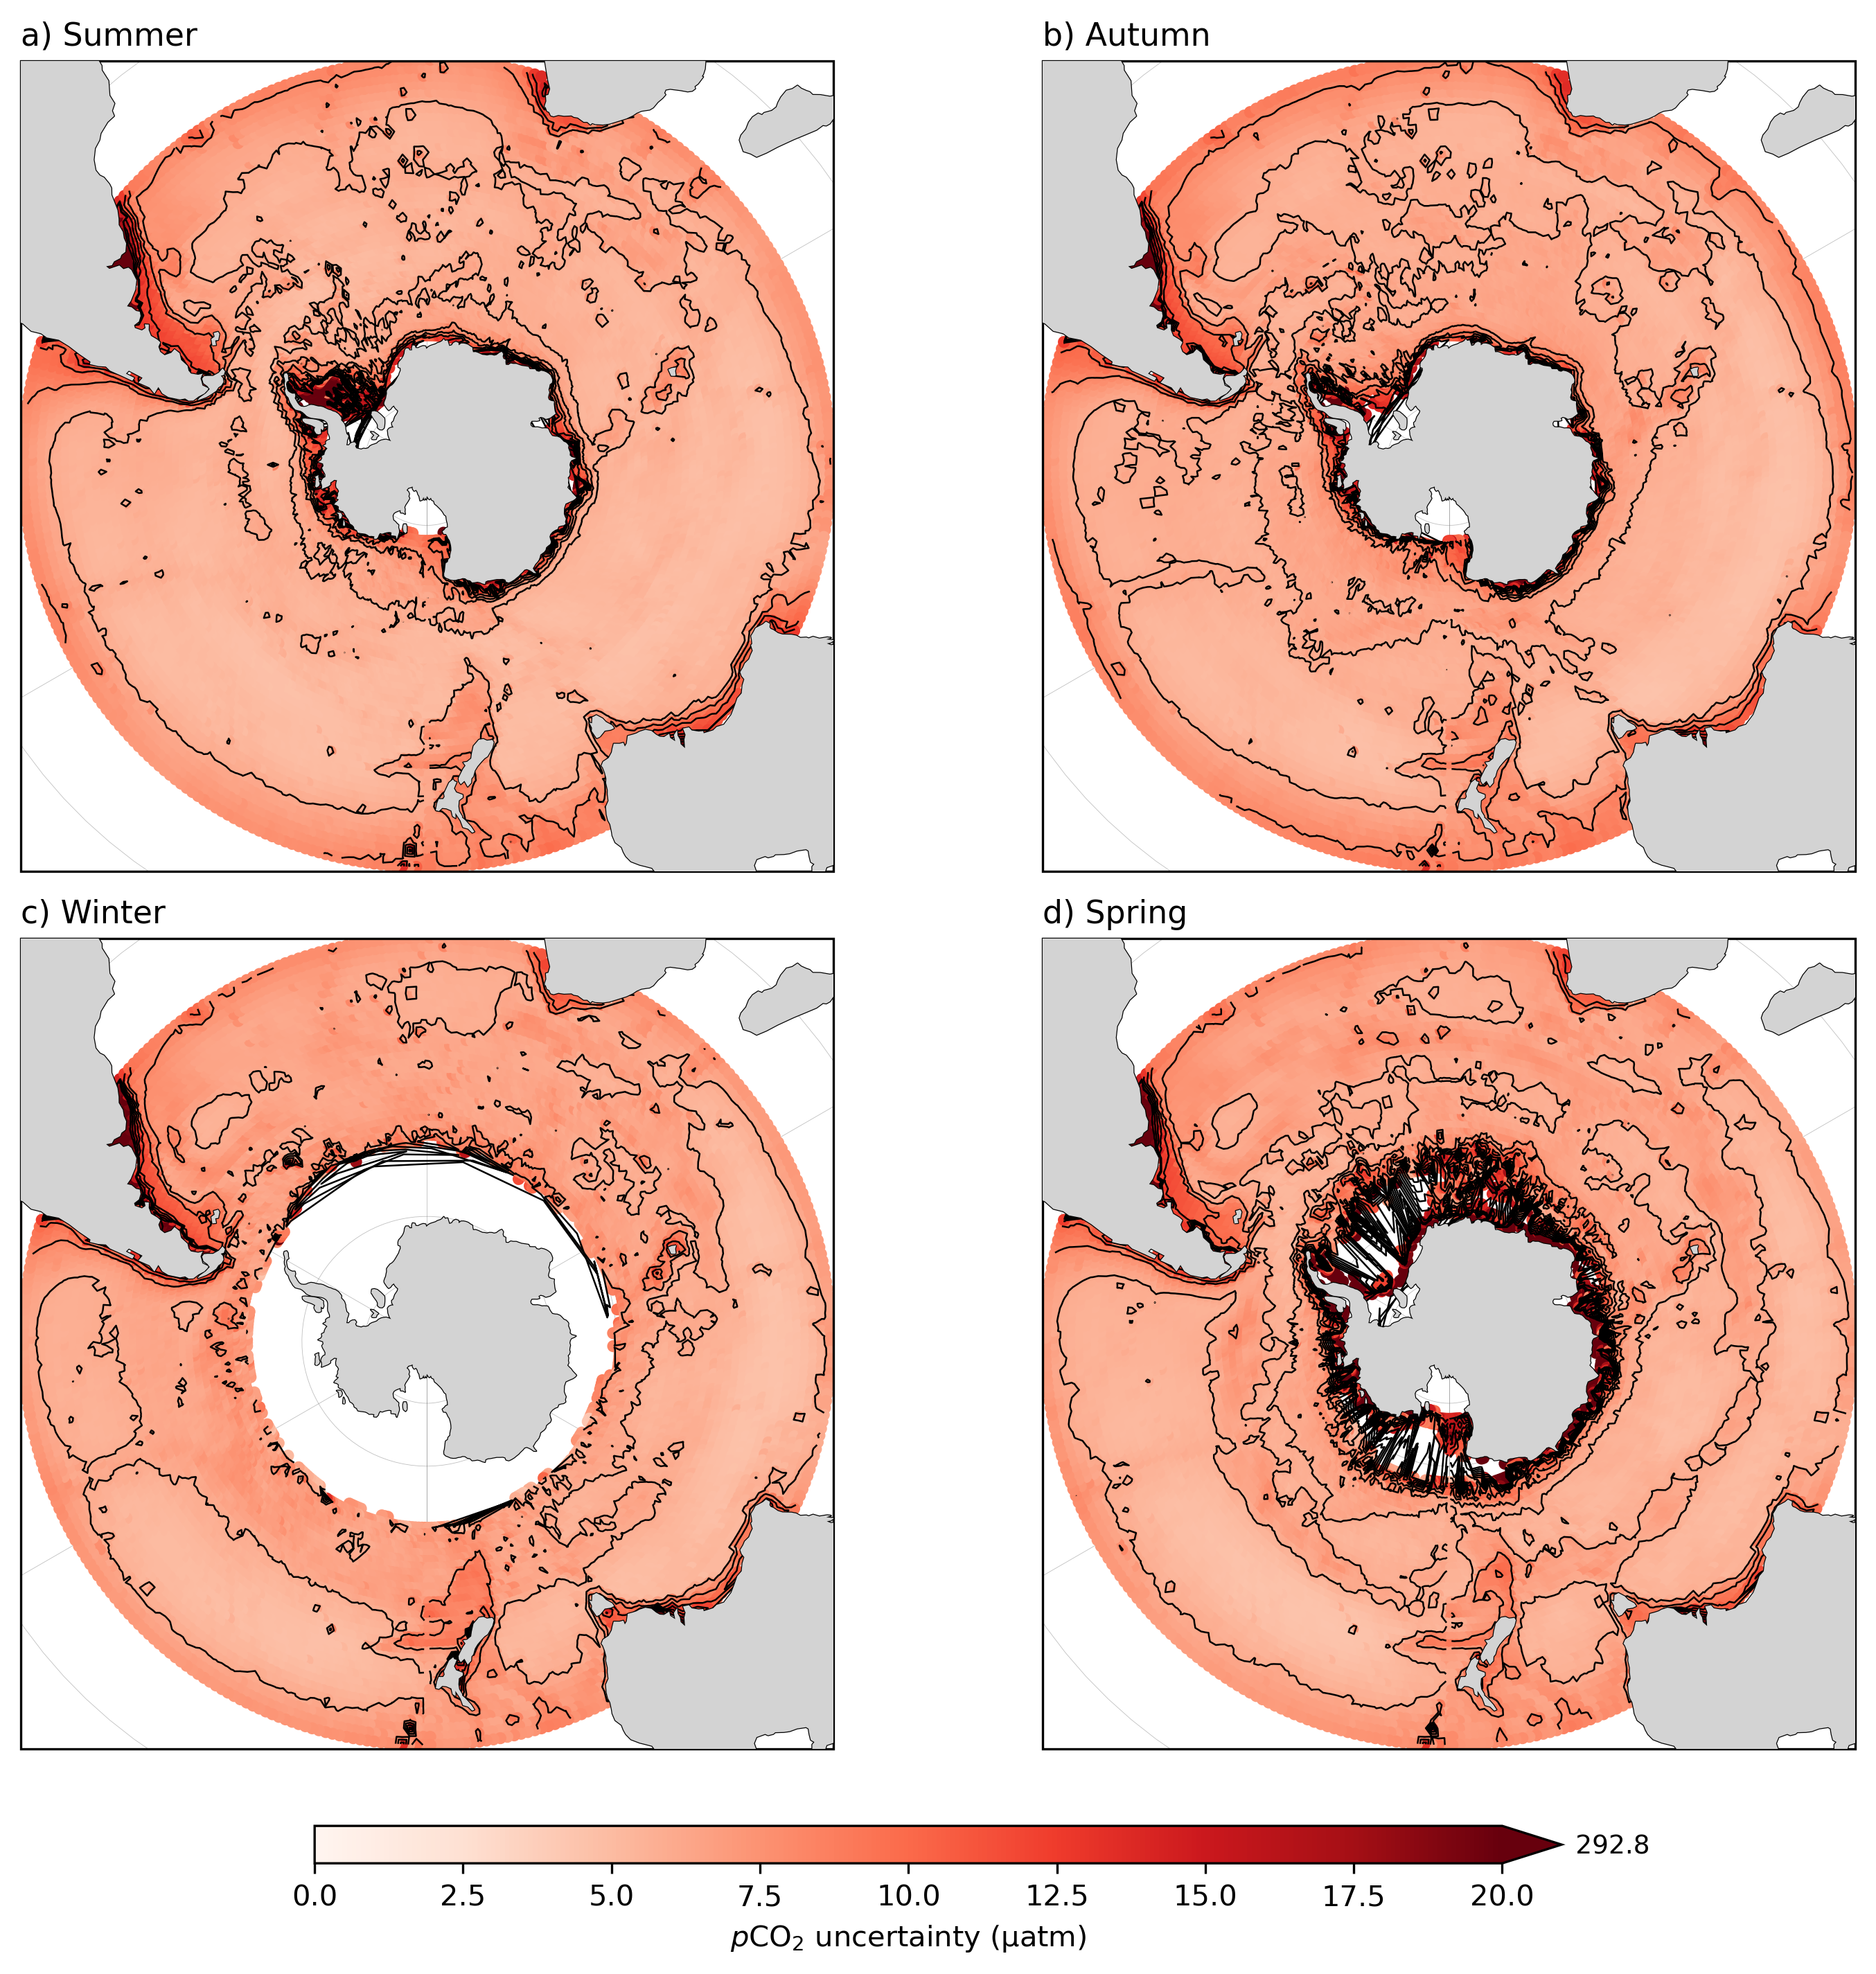

In [13]:
# ============================================================
# 6) PLOT FLOATS SEASONAL UNCERTAINTY
# ============================================================

plot_seasonal_uncertainty_maps(
    seasonal_floats,
    "FLOATS Predictions",
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/figs/"
    "FLOATS_seasonal_MC_uncertainty_maps.png",
    contour_step=2
)